In [1]:
import cobra
from scipy.io import loadmat

In [2]:
folder_path = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/iMat_Models"

## Loading single models and performing FBA, into a dataframe

In [5]:
import os
import cobra
import pandas as pd
from cobra.io import load_matlab_model

def run_fba_and_extract_flux_info(folder_path):
    results = []

    model_files = [f for f in os.listdir(folder_path) if f.endswith('.mat')]

    for file in model_files:
        try:
            full_path = os.path.join(folder_path, file)

            # Load iMAT model from .mat file
            model = load_matlab_model(full_path, variable_name='specificModel')

            # Set biomass objective
            model.objective = "MAR13082"

            # Solve FBA
            solution = model.optimize()

            # Extract values
            sample_id = file.replace("_imat_vector.mat", "")
            condition = "Tumor" if "Tumor" in file else "Healthy"

            # Handle infeasible models
            if solution.status != 'optimal':
                results.append({
                    "sample": sample_id,
                    "condition": condition,
                    "status": solution.status,
                    "objective_value": 0.0,
                    "total_abs_flux": 0.0,
                    "active_reactions": 0
                })
                print(f"⚠️ {sample_id} → {solution.status}")
                continue

            # Total absolute flux
            total_flux = solution.fluxes.abs().sum()

            # Number of active reactions (non-zero flux above tiny epsilon)
            active_rxns = (solution.fluxes.abs() > 1e-6).sum()

            results.append({
                "sample": sample_id,
                "condition": condition,
                "status": solution.status,
                "objective_value": solution.objective_value,
                "total_abs_flux": total_flux,
                "active_reactions": active_rxns
            })

            print(f"✅ {sample_id} | biomass: {solution.objective_value:.4f} | abs_flux: {total_flux:.1f} | active_rxns: {active_rxns}")

        except Exception as e:
            print(f"❌ Error in {file}: {e}")

    return pd.DataFrame(results)

In [8]:
fba_df = run_fba_and_extract_flux_info(folder_path)

✅ TCGA_Tumor_A3A3 | biomass: 124.8597 | abs_flux: 151577.5 | active_rxns: 849
✅ TCGA_Tumor_A3RK | biomass: 124.8681 | abs_flux: 158244.6 | active_rxns: 945


KeyboardInterrupt: 

In [ ]:
fba_df.to_csv("fba_results.csv", index=False)

In [ ]:
fba_df.to_csv("/Users/valentinreateguirangel/dissertation_project/notebooks/fba_results.csv", index=False)

In [7]:
import pandas as pd
fba_df = pd.read_csv("fba_results.csv")

In [9]:
fba_df

,sample,condition,status,objective_value,total_abs_flux,active_reactions
0,TCGA_Tumor_A3A3,Tumor,optimal,124.859749,151577.453199,849
1,TCGA_Tumor_A3RK,Tumor,optimal,124.868148,158244.609113,945
2,TCGA_Tumor_A3KG,Tumor,optimal,124.868148,107372.483261,1002
3,TCGA_Tumor_AAU7,Tumor,optimal,124.867964,129567.000109,1295
4,TCGA_Tumor_A9VH,Tumor,optimal,124.868148,165189.256758,1216
...,...,...,...,...,...,...
418,TCGA_Tumor_A5MZ,Tumor,optimal,124.868148,131739.702932,651
419,TCGA_Tumor_AACD,Tumor,optimal,124.868148,153346.125009,785
420,TCGA_Healthy_A1EG,Healthy,optimal,124.868148,161802.762754,1026
421,TCGA_Tumor_A73D,Tumor,optimal,124.868148,133986.302901,1005


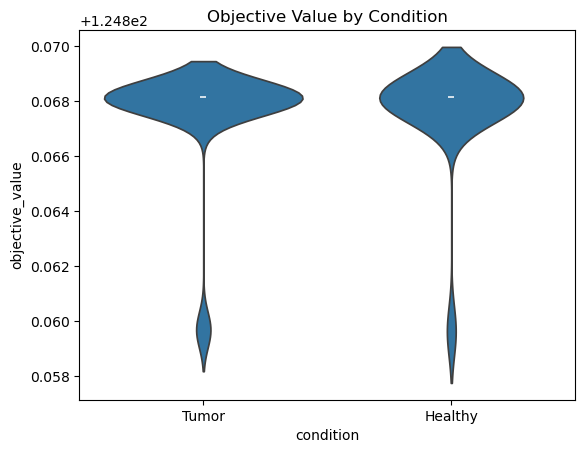

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=fba_df, x='condition', y='objective_value')
plt.title("Objective Value by Condition")
plt.show()

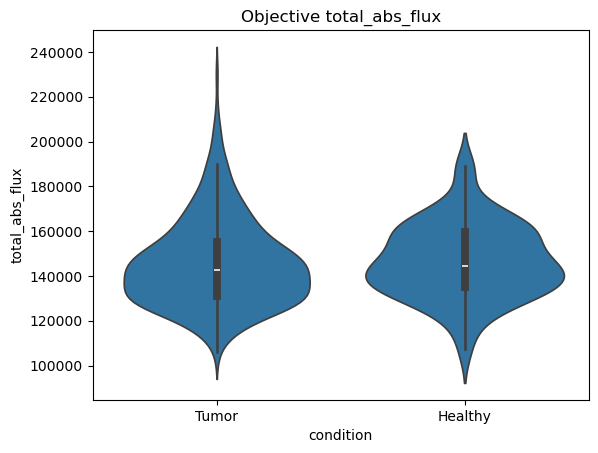

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=fba_df, x='condition', y='total_abs_flux')
plt.title("Objective total_abs_flux")
plt.show()

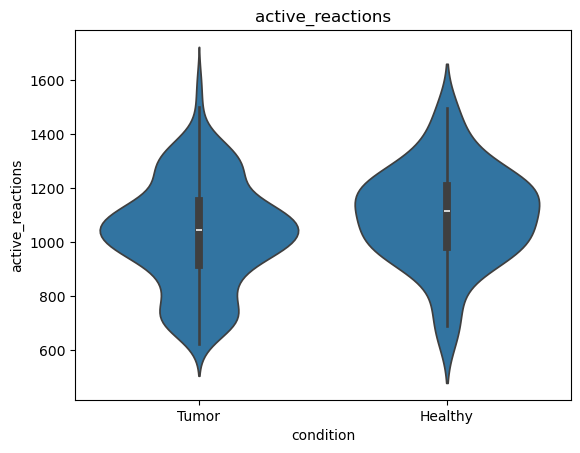

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=fba_df, x='condition', y='active_reactions')
plt.title("active_reactions")
plt.show()

In [17]:
from scipy.stats import mannwhitneyu

metric = 'objective_value' 
healthy = fba_df[fba_df['condition'] == 'Healthy'][metric]
tumor = fba_df[fba_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy, tumor, alternative='two-sided')
print(f"{metric} Mann–Whitney U:\nStatistic = {stat:.4f}, p = {p:.4f}")

objective_value Mann–Whitney U:
Statistic = 9360.0000, p = 0.7271


In [19]:
from scipy.stats import mannwhitneyu

metric = 'total_abs_flux'  
healthy = fba_df[fba_df['condition'] == 'Healthy'][metric]
tumor = fba_df[fba_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy, tumor, alternative='two-sided')
print(f"{metric} Mann–Whitney U:\nStatistic = {stat:.4f}, p = {p:.4f}")

total_abs_flux Mann–Whitney U:
Statistic = 10445.0000, p = 0.3335


In [21]:
from scipy.stats import mannwhitneyu

metric = 'active_reactions'  
healthy = fba_df[fba_df['condition'] == 'Healthy'][metric]
tumor = fba_df[fba_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy, tumor, alternative='two-sided')
print(f"{metric} Mann–Whitney U:\nStatistic = {stat:.4f}, p = {p:.4f}")

active_reactions Mann–Whitney U:
Statistic = 11563.0000, p = 0.0203


## Cliffs Delta

Cliff's Delta Value: 
Interpretation
delta < 0.147 Negligible ///  0.147 ≤ |delta| < 0.330 Small /// 0.330 < delta < 0.474 Medium /// delta ≥ 0.474  Large

In [29]:
import numpy as np
from cliffs_delta import cliffs_delta  

# Split groups
healthy = fba_df[fba_df['condition'] == 'Healthy']['active_reactions']
tumor = fba_df[fba_df['condition'] == 'Tumor']['active_reactions']

# Compute Cliff's Delta
delta, size = cliffs_delta(tumor.values, healthy.values)

print(f"Cliff's Delta: {delta:.4f} ({size} effect)")

Cliff's Delta: -0.1987 (small effect)
